In [1]:
# 1 Этап. Загрузка данных

# Импортирую необходимые библиотеки
import pandas as pd
import sqlite3 as sql
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Сохранил в отдельные переменную путь до csv-файлов и подключение к базе данных SQL
data_path = 'C:/Users/terme/Downloads/olist-project/data/'
conn = sql.connect('olist.db')

# Сохранил в словарь csv-файлы по ключам (их названиям)
csv_files = {
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'customers': 'olist_customers_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv'
}

# Загрузил каждый файл при помощи цикла в SQLite
for table_name, file_name in csv_files.items():
    file_path = os.path.join(data_path, file_name)
# Здесь я проверяю нахождение файла (датасета) в системе 
# Если датасет существует, то в базе данных SQL создаю таблицу, либо перезаписываю ее, если она уже существует и убираю индексы из pandas
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        df.to_sql(table_name, conn, if_exists='replace', index=False)

In [2]:
# 2 Этап. Проверка данных

# Загрузил все таблицы в pandas
orders = pd.read_sql_query("SELECT * FROM orders", conn)
order_items = pd.read_sql_query("SELECT * FROM order_items", conn)
customers = pd.read_sql_query("SELECT * FROM customers", conn)
products = pd.read_sql_query("SELECT * FROM products", conn)
sellers = pd.read_sql_query("SELECT * FROM sellers", conn)
payments = pd.read_sql_query("SELECT * FROM payments", conn)
reviews = pd.read_sql_query("SELECT * FROM reviews", conn)
geolocation = pd.read_sql_query("SELECT * FROM geolocation", conn)

In [3]:
# Смотрим на описательную статистику данных
tables = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'payments': payments,
    'reviews': reviews,
    'geolocation': geolocation
}
for name, df in tables.items():
    print(f'Таблица {name}:\n{df.describe()}\n')

Таблица orders:
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                             99441   
top     e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
freq                                   1                                 1   

       order_status order_purchase_timestamp    order_approved_at  \
count         99441                    99441                99281   
unique            8                    98875                90733   
top       delivered      2018-04-11 10:48:14  2018-02-27 04:31:10   
freq          96478                        3                    9   

       order_delivered_carrier_date order_delivered_customer_date  \
count                         97658                         96476   
unique                        81018                         95664   
top             2018-05-09 15:48:00     

In [4]:
# Проверка на наличие нулевых значений и дубликатов в данных
tables = {
    'orders': orders,
    'order_items': order_items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'payments': payments,
    'reviews': reviews,
    'geolocation': geolocation
}
for name, df in tables.items():
    print(f'Таблица {name}:\n{df.isnull().sum()}\nКоличество дубликатов: {df.duplicated().sum()}\n\n')

Таблица orders:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Количество дубликатов: 0


Таблица order_items:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Количество дубликатов: 0


Таблица customers:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
Количество дубликатов: 0


Таблица products:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product

In [5]:
# Вывод: нужно быть аккуратным с таблицами, в которых присутствуют нулевые значения или дубликаты,
# чтобы полученные метрики в ходе анализа не были искажены

In [6]:
# 3 Этап. Общая статистика
# В этом блоке я смотрю количество заказов и количество уникальных покупателей
# Также ищу даты первого и крайнего заказа, чтобы узнать за какой период данные
query = """
SELECT 
    COUNT(o.order_id) AS Количество_заказов,
    COUNT(DISTINCT (c.customer_unique_id)) AS Количество_уникальных_покупателей,
    MIN(o.order_purchase_timestamp) AS Дата_первого_заказа,
    MAX(o.order_purchase_timestamp) AS Дата_крайнего_заказа
FROM orders o JOIN customers c USING (customer_id)
"""
df = pd.read_sql(query, conn)
df

,Количество_заказов,Количество_уникальных_покупателей,Дата_первого_заказа,Дата_крайнего_заказа
0,99441,96096,2016-09-04 21:15:19,2018-10-17 17:30:18


In [7]:
# Вывод: данные прдеставлены в период с 4 сентября 2016 по 17 октября 2018

In [8]:
# В этом блоке смотрим на количество заказов за каждый год, чтобы выявить самый успешный в этом показателе
query1 = """
SELECT STRFTIME('%Y', order_purchase_timestamp) AS Год,
    COUNT (*) AS Количество_заказов
FROM orders
WHERE STRFTIME('%Y', order_purchase_timestamp) = '2017'
"""
df1 = pd.read_sql(query1, conn)
display(df1);
query2 = """
SELECT 
    STRFTIME('%Y', order_purchase_timestamp) AS Год,
    COUNT (*) AS Количество_заказов
FROM orders
GROUP BY STRFTIME('%Y', order_purchase_timestamp)
ORDER BY Количество_заказов DESC
"""
df2 = pd.read_sql(query2, conn)
display(df2) 

,Год,Количество_заказов
0,2017,45101


,Год,Количество_заказов
0,2018,54011
1,2017,45101
2,2016,329


In [9]:
# Нашел топ-3 товара в каждой категории
query = """
WITH product_sales AS
(
SELECT
    p.product_category_name,
    oi.product_id,
    COUNT(*) AS sales_count,
    ROW_NUMBER() OVER(PARTITION BY p.product_category_name
                      ORDER BY COUNT(*) DESC) AS rank
FROM order_items oi JOIN products p USING (product_id)
GROUP BY p.product_category_name, oi.product_id
)
SELECT *
FROM product_sales
WHERE rank <= 3
ORDER BY product_category_name, rank
"""
df = pd.read_sql(query, conn)
df

,product_category_name,product_id,sales_count,rank
0,None,5a848e4ab52fd5445cdc07aab1c40e48,197,1
1,None,b1d207586fca400a2370d50a9ba1da98,48,2
2,None,76d1a1a9d21ab677a61c3ae34b1b352f,32,3
3,agro_industria_e_comercio,11250b0d4b709fee92441c5f34122aed,22,1
4,agro_industria_e_comercio,423a6644f0aa529e8828ff1f91003690,18,2
...,...,...,...,...
214,telefonia_fixa,b4f9530c931398e215242293c2c8ba4c,14,2
215,telefonia_fixa,4633dfeb3a2588bdb52af32d504b44eb,12,3
216,utilidades_domesticas,42a2c92a0979a949ca4ea89ec5c7b934,183,1
217,utilidades_domesticas,5a6e53c3b4e8684b13388d6aa4afdf12,73,2


In [10]:
# Анализ статусов заказов
query = """
SELECT 
    order_status AS Статус_заказа,
    COUNT(*) AS Количество,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) AS Процент    
FROM orders
GROUP BY Статус_заказа
ORDER BY Процент DESC"""
df = pd.read_sql(query, conn)
df

,Статус_заказа,Количество,Процент
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


In [11]:
# Инсайт: 97% заказов были успешно выполнены (доставлены до покупателей), что является хорошим показателем для бразильского рынка

In [12]:
# Посчитал общее количество товаров в каждом заказе, общую стоимость заказа
# А также посчитал средний чек и средний размер корзины
query = """
SELECT
    o.order_id,
    COUNT(*) AS Количество_товаров_в_заказе,
    SUM(oi.price) AS Стоимость_заказа
FROM orders o JOIN order_items oi USING (order_id)
GROUP BY o.order_id
ORDER BY Количество_товаров_в_заказе DESC, Стоимость_заказа DESC
"""
df = pd.read_sql(query, conn)
display(df)
avg_basket_size = df['Количество_товаров_в_заказе'].mean()
avg_check = df['Стоимость_заказа'].mean()
print (f"""Средний чек - {round(avg_check, 2)}
Средний размер корзины - {round(avg_basket_size, 2)}""")

,order_id,Количество_товаров_в_заказе,Стоимость_заказа
0,8272b63d03f5f79c56e9e4120aec44ef,21,31.80
1,1b15974a0141d54e36626dca3fdc731a,20,2000.00
2,ab14fdcfbe524636d65ee38360e22ce8,20,1974.00
3,428a2f660dc84138d969ccd69a0ab6d5,15,982.35
4,9ef13efd6949e4573a18964dd1bbe7f5,15,765.00
...,...,...,...
98661,38bcb524e1c38c2c1b60600a80fc8999,1,2.90
98662,e8bbc1d69fee39eee4c72cb5c969e39d,1,2.29
98663,f1d5c2e6867fa93ceee9ef9b34a53cbf,1,2.20
98664,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,0.85


Средний чек - 137.75
Средний размер корзины - 1.14


In [13]:
# Инсайты:
# - Средний чек: 137.55 BRL, R$ (~₽2038,7 RUB)
# - Средний размер корзины: 1.14 товара

# Выводы: 
# По той статистике, которую я смог найти, ясно, что это очень слабые показатели. Такими они являются из-за того,
# что 97% покупателей сделали всего один заказ (это уже было видно в начале 3 Этапа).
# Следовательно рост среднего чека и среднего размера корзины невозможен без увеличения доли повторных покупок.
# Пока клиенты не возвращаются для повторной покупки, чек и корзина будут оставаться на этом минимальном уровне

,Категория_товара,orders_count,Выручка,Средняя_цена
0,beleza_saude,9670,1258681.34,130.16
1,relogios_presentes,5991,1205005.68,201.14
2,cama_mesa_banho,11115,1036988.68,93.30
3,esporte_lazer,8641,988048.97,114.34
4,informatica_acessorios,7827,911954.32,116.51
5,moveis_decoracao,8334,729762.49,87.56
6,cool_stuff,3796,635290.85,167.36
7,utilidades_domesticas,6964,632248.66,90.79
8,automotivo,4235,592720.11,139.96
9,ferramentas_jardim,4347,485256.46,111.63


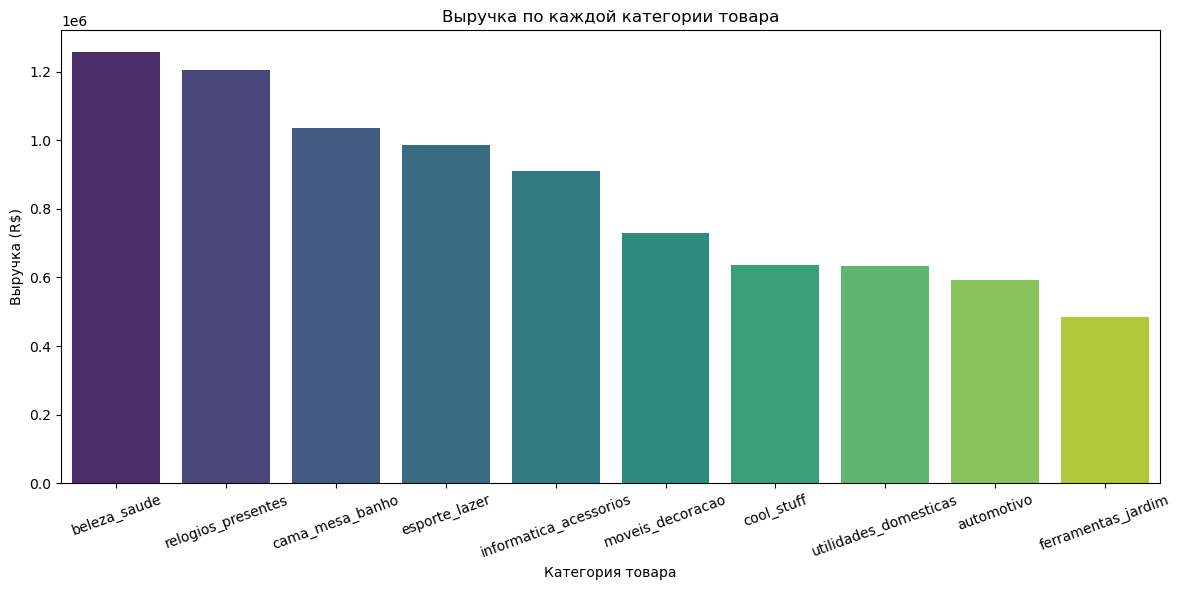

,Категория_товара,orders_count
0,cama_mesa_banho,11115
1,beleza_saude,9670
2,esporte_lazer,8641


,Процент
0,39.7


In [14]:
# 4 Этап. Анализ выручки по категориям товаров
query1 = """
SELECT 
    p.product_category_name AS Категория_товара,
    COUNT(oi.order_id) as orders_count,
    SUM(oi.price) AS Выручка,
    ROUND(AVG(oi.price), 2) AS Средняя_цена
FROM order_items oi 
    JOIN products p USING (product_id)
GROUP BY p.product_category_name
ORDER BY Выручка DESC
LIMIT 10
"""
df1 = pd.read_sql(query1, conn)
display(df1)
plt.figure(figsize = (12, 6))
sns.barplot(data = df1, x = 'Категория_товара', y = 'Выручка', hue = 'Категория_товара', palette = 'viridis')
plt.title('Выручка по каждой категории товара')
plt.xlabel('Категория товара')
plt.ylabel('Выручка (R$)')
plt.xticks(rotation = 20)
plt.tight_layout()
plt.savefig('visualizations/Выручка по каждой категории товара.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Ниже посмотрел топ-3 категории товаров по количеству заказов

query2 = """
SELECT 
    p.product_category_name AS Категория_товара,
    COUNT(oi.order_id) as orders_count
FROM order_items oi JOIN products p USING (product_id)
GROUP BY p.product_category_name
ORDER BY orders_count DESC
LIMIT 3
"""
df2 = pd.read_sql(query2, conn)
display(df2)

# Посмотрю долю топ-5 товаров от общей выручки
query3 = """
WITH revenue_by_product_category AS
(
    SELECT 
        p.product_category_name AS Категория_товара,
        COUNT(oi.order_id) as orders_count,
        SUM(oi.price) AS revenue,
        ROUND(AVG(oi.price), 2) AS Средняя_цена,
        ROW_NUMBER() OVER(ORDER BY SUM(oi.price) DESC) AS rank
    FROM order_items oi 
        JOIN products p USING (product_id)
    GROUP BY p.product_category_name
    ORDER BY revenue DESC
)
SELECT 
    ROUND((SELECT SUM(revenue) FROM revenue_by_product_category WHERE rank <= 5) * 100.0 / SUM(revenue), 1) AS Процент
FROM revenue_by_product_category
"""
df3 = pd.read_sql(query3, conn)
display(df3)

In [15]:
# Ключевые инсайты:

# Топ-5 товара по выручке:
# 1. beleza_saude (красота и здоровье) - 1,258,681.34 R$
# 2. relogios_presentes (часы и подарки) - 1,205,005.68 R$
# 3. cama_mesa_banho (товары для дома) - 1,036,988.68 R$
# 4. esporte_lazer (спорт и отдых) - 988,048.97 - R$
# 5. informatica_acessorios (компьютерные аксессуары) - 911,954.32 R$

# Выводы: Эти 5 категорий составляют ~40% от общей выручки - можно рекомендовать увеличить фокус маркетинга на них

In [16]:
#5 Этап. Анализ типов оплаты
query1 = """
SELECT 
    payment_type AS Тип_оплаты,
    COUNT(*) AS Количество,
    ROUND(AVG(payment_value), 2) AS Средний_чек,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM payments), 1) AS Процент
FROM payments	
GROUP BY Тип_оплаты
ORDER BY Количество DESC
"""
df1 = pd.read_sql(query1, conn)
display(df1)

,Тип_оплаты,Количество,Средний_чек,Процент
0,credit_card,76795,163.32,73.9
1,boleto,19784,145.03,19.0
2,voucher,5775,65.70,5.6
3,debit_card,1529,142.57,1.5
4,not_defined,3,0.00,0.0


In [17]:
# Инсайты:
# 1. Credit card - 73.9% (самый популярный)
# 2. Boleto - 19.0% (бразильский платежный метод)
# 3. Voucher/Debit - 7.1%

# Выводы:
# - Бразильцы предпочитают проводить оплату кредитными картами, в том числе и в рассрочку.
# - Boleto bancário (банкоовский билет) - национальная специфика. Данный тип оплаты используют те, у кого не карты,
# либо кто не доверяет онлайн-платежам.
# - Voucher - подозрительно низкий чек (65.7 R$), но, скорее всего, это подарочные сертификаты и их тратят на мелкие покупки
# - Debit - очень маленький процент, но это особенность их страны

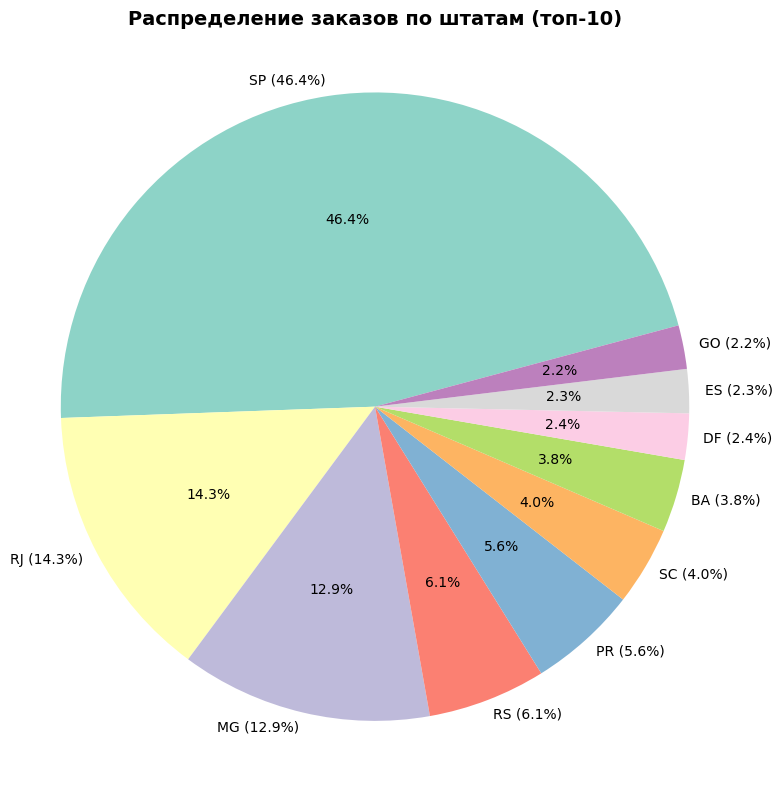

In [18]:
# 6 Этап. Анализ распределния заказов по штатам (возьму только первые десять)
query = """SELECT 
    c.customer_state AS Штаты_откуда_поступали_заказы,
    COUNT(o.order_id) AS Количество_заказов
FROM orders o JOIN customers c USING (customer_id)
GROUP BY Штаты_откуда_поступали_заказы
ORDER BY Количество_заказов DESC
LIMIT 10
"""
df = pd.read_sql(query, conn)
df
plt.figure(figsize = (8, 8))
colors = plt.cm.Set3(range(len(df)))
labels = [f"{state} ({count/df['Количество_заказов'].sum()*100:.1f}%)" 
          for state, count in zip(df['Штаты_откуда_поступали_заказы'], df['Количество_заказов'])]
plt.pie(df['Количество_заказов'], labels=labels, colors=colors, 
        autopct='%1.1f%%', startangle=15, labeldistance = 1.05, textprops={'fontsize': 10})
plt.title('Распределение заказов по штатам (топ-10)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.savefig('visualizations/Распределение заказов по штатам.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [19]:
# Ключевые инсайты:
# 1. Абсолютным лидером является Сан-Паулу (SP) - почти половина всех заказов по стране (46.4%).
# 2. Юго-восточный регион доминирует над остальными: SP (46.4%) + RJ (14.3%) + MG (12.9%) + ES (2.3%) = 75.9% всех заказов.
# 3. Южные штаты (RS, PR, SC) генерируют 15.7% заказов, что делает их вторым по значимости макрорегионов
# 4. Баия (BA) - единственный представитель Северо-Востока в топ-10 с долей 3.8%. Это самый густонаселенный штат региона 
# и логистические ворота для всего Северо-Востока. Увеличение присутствия здесь может открыть доступ к огромной аудитории.

# Выводы:
# - Усилить логистику в Сан-Паулу (SP) и Рио-де-Жанейро (RJ), поскольку 60% заказов идут из этих двух штатов, поэтому
# необходимо иметь там больше складов с быстрой доставкой.
# - Надо потестить маркетинг на Северо-Восток, как минимум ради Баии, возможно, подтянутся и другие штаты
# - Обратить внимание на то, что бизнес работает только в развитом Юго-Востоке и Юге. 
# Это не плохо, но для роста нужно либо углубляться здесь, либо пробовать продвижение в новых штатах

In [20]:
# 7 Этап. Вычисление коэффициента повторных покупок
query = """
WITH customer_orders AS 
(
SELECT
    customer_unique_id AS Уникальный_клиент,
    COUNT(*) AS Количество_заказов
FROM customers
GROUP BY customer_unique_id
)
SELECT
    COUNT(CASE WHEN Количество_заказов > 1 THEN 1 END) AS Покупатели_с_повторной_покупкой,
    COUNT(*) AS Общее_количество_покупателей,
    ROUND(COUNT(CASE WHEN Количество_заказов > 1 THEN 1 END) * 100.0 / COUNT(*), 2) AS Процент_повторной_покупки
FROM customer_orders
"""
df = pd.read_sql(query, conn)
df

,Покупатели_с_повторной_покупкой,Общее_количество_покупателей,Процент_повторной_покупки
0,2997,96096,3.12


In [21]:
# Инсайт:
# Только 3.12% клиентов вернулись за повторной покупкой. Это очень низкий показатель по статистике, 
# которую я нашел, на 2025 год - средний показатель удержания клиентов в магазинах электронной коммерции - 30-40%

# Вывод:
# В качестве рекомендаций можно посоветовать:
# 1. Проверить наличие достаточного количества складов и быстрой доставки в проблематичных штатах (в следующем этапе я это проанализировал)
# 2. Добавить программу лояльности
# 3. Push-уведомления о новых товарах в интересующих категориях (скорее всего, при помощи куки понять интересы пользователей)

,Среднее_количество_дней_доставки
0,12.56


,Штат_покупателя,Количество_заказов,avg_number_of_delivery_days
0,RR,41,29.39
1,AP,67,27.19
2,AM,145,26.43
3,AL,397,24.54
4,PA,946,23.77
5,MA,717,21.57
6,SE,335,21.52
7,CE,1279,21.27
8,AC,80,21.04
9,PB,517,20.43


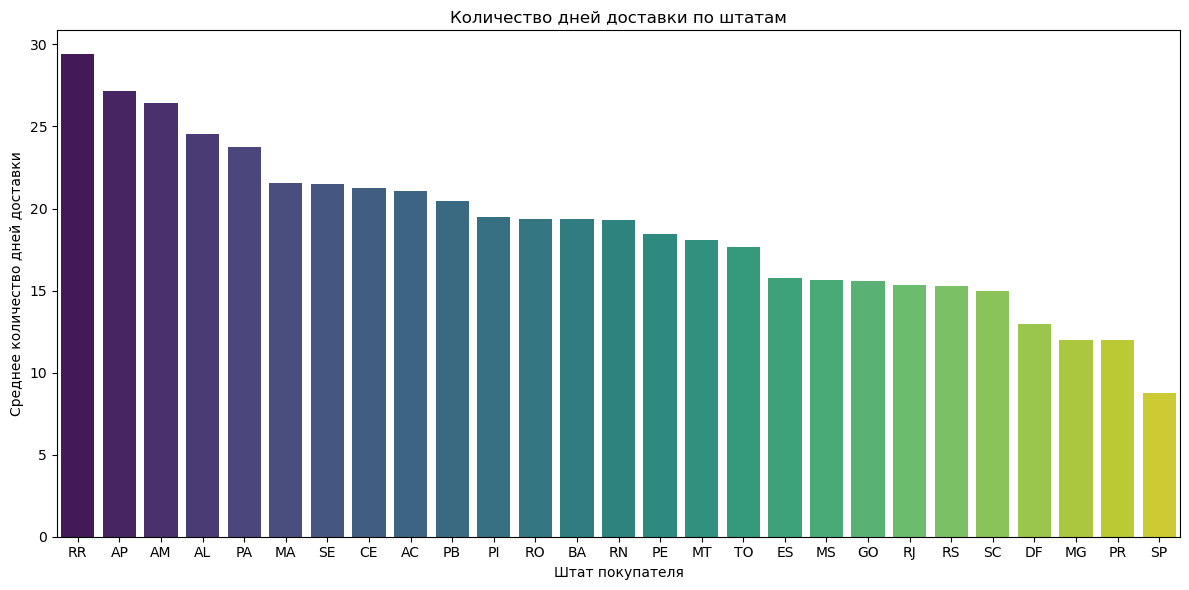

In [22]:
# 8 Этап. Анализ времени доставки по штатам
query1 = """
WITH avg_days AS
(
SELECT 
    order_id,
    customer_id,
    ROUND(JULIANDAY(order_delivered_customer_date) - JULIANDAY(order_purchase_timestamp), 2) AS number_of_delivery_days
FROM orders
WHERE order_delivered_customer_date IS NOT NULL
)
SELECT ROUND(AVG(number_of_delivery_days), 2) AS Среднее_количество_дней_доставки
FROM avg_days
"""
df1 = pd.read_sql(query1, conn)
display(df1)
query2 = """
SELECT
    c.customer_state AS Штат_покупателя,
    COUNT(*) AS Количество_заказов,
    ROUND(AVG(JULIANDAY(o.order_delivered_customer_date) - JULIANDAY(o.order_purchase_timestamp)), 2) AS avg_number_of_delivery_days
FROM orders o JOIN customers c USING (customer_id)
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY Штат_покупателя
ORDER BY avg_number_of_delivery_days DESC
"""
df2 = pd.read_sql(query2, conn)
display(df2)
plt.figure(figsize = (12, 6))
sns.barplot(data = df2, x = 'Штат_покупателя', y = 'avg_number_of_delivery_days', hue = 'Штат_покупателя', palette = 'viridis')
plt.title('Количество дней доставки по штатам')
plt.xlabel('Штат покупателя')
plt.ylabel('Среднее количество дней доставки')
plt.tight_layout()
plt.savefig('visualizations/Количество дней доставки по штатам.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [23]:
# Ключевые инсайты:
# 1. Самые проблематичные штаты находятся на Севере и Северо-Востоке Бразилии: RR (29 дней), AP (27 дней), AM (26 дней),
# AL, PA, MA, SE, CE (21-24 дня)
# 2. У Юго-Восточных и Южных штатов лучшие показатели: SP (9 дней), RJ (15 дней), ES (16 дней), MS (16 дней) и т.д.

# Выводы:
# - Открыть дополнительные склады на Северо-Востоке, т.к. там больше населения и будет проще наладить логистику благодаря портам
# - Партнерство с локальными курьерскими службами
# - Усилить логистику в Сан-Паулу (SP) и Рио-де-Жанейро (RJ), поскольку 60% заказов идут из этих двух штатов, поэтому
# необходимо иметь там больше складов с быстрой доставкой (выше разбирал этот вывод)

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,160.3,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,163.3,1,27.19
2,0000f46a3911fa3c0805444483337064,585.9,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,369.9,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,336.9,1,196.89
...,...,...,...,...
93352,fffcf5a5ff07b0908bd4e2dbc735a684,495.9,1,2067.42
93353,fffea47cd6d3cc0a88bd621562a9d061,310.9,1,84.58
93354,ffff371b4d645b6ecea244b27531430a,617.1,1,112.46
93355,ffff5962728ec6157033ef9805bacc48,168.1,1,133.69


segment
One-time    90556
Regular      2787
VIP            14
Name: count, dtype: int64


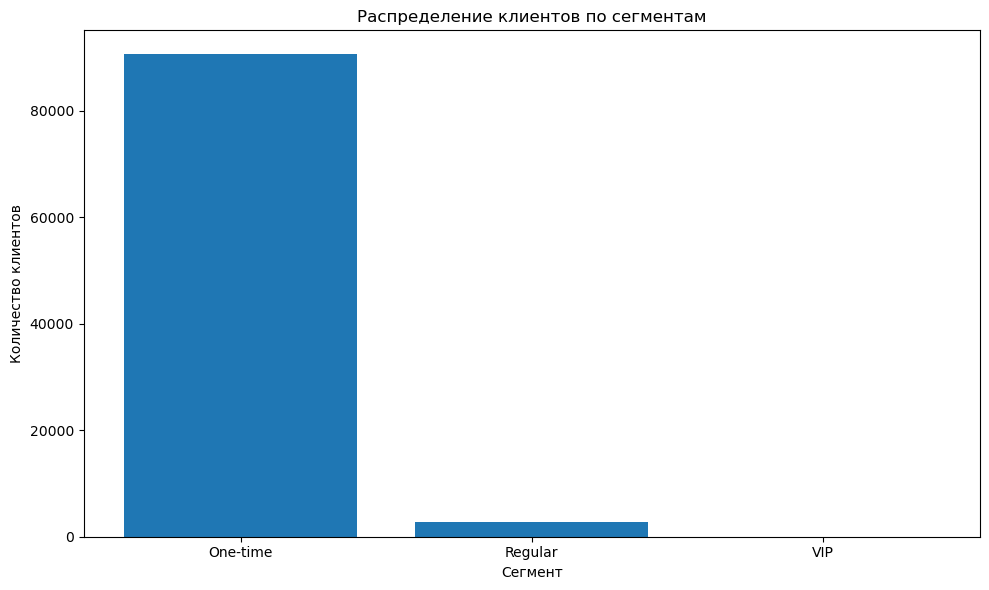

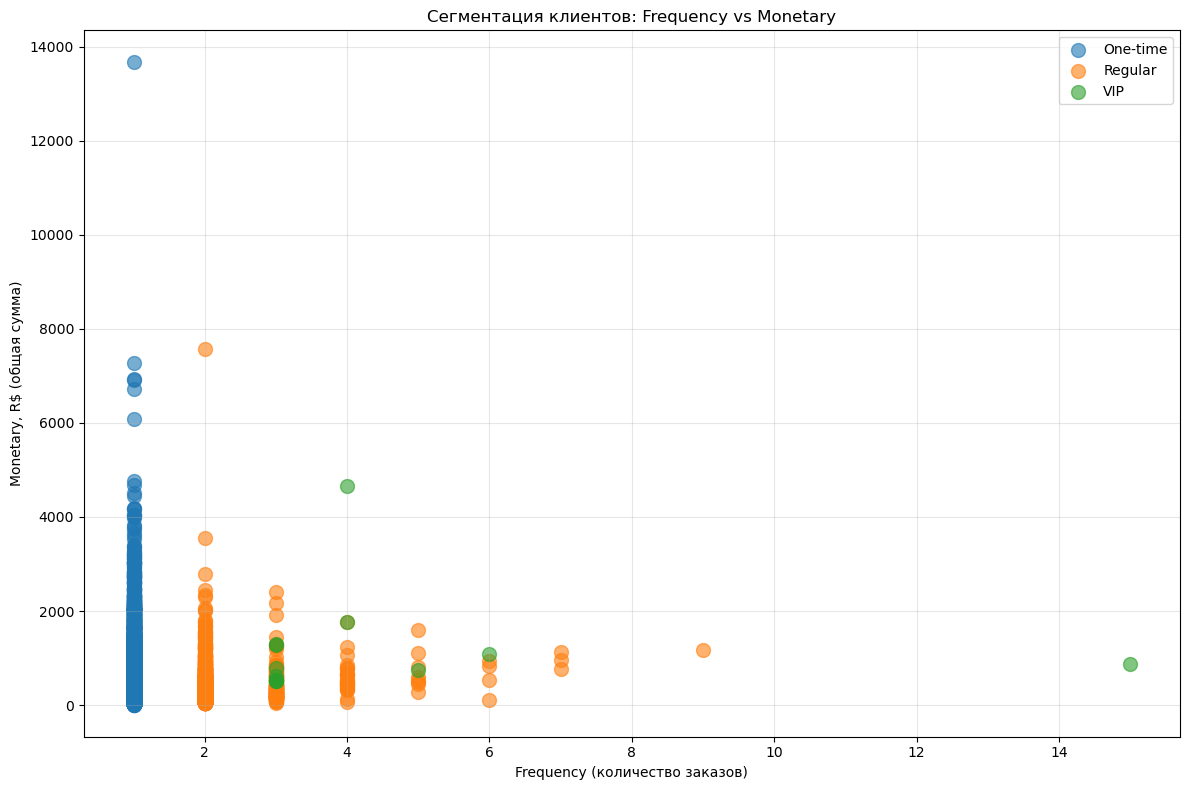

          Количество  Среднее_количество_дней_с_последнего_заказа  \
segment                                                             
One-time       90556                                       287.11   
Regular         2787                                       269.90   
VIP               14                                        72.12   

          Среднее_количество_заказов  Средняя_потраченная_сумма  
segment                                                          
One-time                        1.00                     160.76  
Regular                         2.10                     304.49  
VIP                             4.36                    1124.14  


In [24]:
# RFM-анализ
query = """
SELECT
    c.customer_unique_id,
    ROUND(JULIANDAY((SELECT MAX(order_purchase_timestamp) FROM orders)) - JULIANDAY(MAX(o.order_purchase_timestamp)), 1) AS recency,
    COUNT(DISTINCT(o.order_id)) AS frequency,
    ROUND(SUM(p.payment_value), 2) AS monetary
FROM orders o 
    JOIN payments p USING (order_id)
    JOIN customers c USING (customer_id)
WHERE order_status = 'delivered'
GROUP BY c.customer_unique_id
"""
rfm = pd.read_sql(query, conn)
display(rfm)

# Делаю сегментацию по трем простым сегментам: VIP, Regular и One-time
def segment(row):
    r = row['recency']
    f = row['frequency']
    m = row['monetary']
    if r < 90 and f > 2 and m > 500:
        return 'VIP'
    elif f > 1:
        return 'Regular'
    else:
        return 'One-time'
rfm['segment'] = rfm.apply(segment, axis=1)
print(rfm['segment'].value_counts())

# Распределение по сегментам
plt.figure(figsize=(10, 6))
segment_counts = rfm['segment'].value_counts()
plt.bar(segment_counts.index, segment_counts.values)
plt.title('Распределение клиентов по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.savefig('visualizations/Распределение клиентов по сегментам.png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Scatter plot: Frequency vs Monetary
plt.figure(figsize=(12, 8))
for segment in rfm['segment'].unique():
    segment_data = rfm[rfm['segment'] == segment]
    plt.scatter(segment_data['frequency'], 
                segment_data['monetary'], 
                label=segment, 
                alpha=0.6,
                s=100)

plt.xlabel('Frequency (количество заказов)')
plt.ylabel('Monetary, R$ (общая сумма)')
plt.title('Сегментация клиентов: Frequency vs Monetary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/Сегментация клиентов (Frequency vs Monetary).png', dpi = 300, bbox_inches = 'tight')
plt.show()

# Статистика по сегментам
segment_stats = rfm.groupby('segment').agg({
    'customer_unique_id': 'count',
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean'
}).round(2)

segment_stats.columns = ['Количество', 'Среднее_количество_дней_с_последнего_заказа', 'Среднее_количество_заказов', 'Средняя_потраченная_сумма']
print(segment_stats)

In [25]:
# Инсайты:
# 1. One-time клиенты (синие точки) - сконцентрированы в левом нижнем углу (frequency=1, низкие суммы)
# 2. Regular клиенты (оранжевые точки) - разбросаны шире (2-5 заказов)
# 3. VIP клиенты (зеленые точки) - широко разбросаны (много заказов + большие суммы)

# Вывод: 
# Чётко видна сегментация. VIP-клиентов мало, но они приносят значительную выручку.

,Месяц,Количество_заказов,Количество_клиентов,Выручка
0,2016-09,3,6,267.36
1,2016-10,308,363,49507.66
2,2016-12,1,1,10.90
3,2017-01,789,955,120312.87
4,2017-02,1733,1951,247303.02
5,2017-03,2641,3000,374344.30
6,2017-04,2391,2684,359927.23
7,2017-05,3660,4136,506071.14
8,2017-06,3217,3583,433038.60
9,2017-07,3969,4519,498031.48


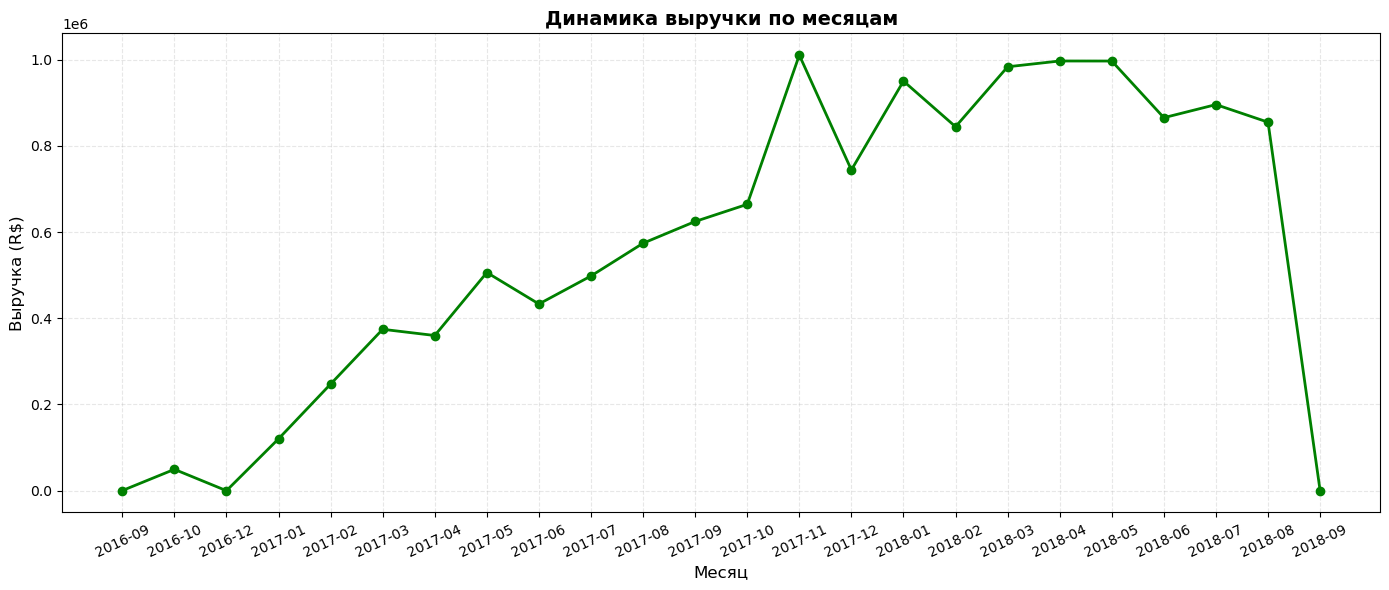

In [26]:
# Провожу когортный анализ, чтобы проверить: как растут продажи по месяцам и есть ли сезонность.
query = """
SELECT
    STRFTIME('%Y-%m', order_purchase_timestamp) AS Месяц,
    COUNT(DISTINCT (o.order_id)) AS Количество_заказов,
    COUNT(customer_unique_id) AS Количество_клиентов,
    ROUND(SUM(oi.price), 2) AS Выручка
FROM orders o
    JOIN customers c USING (customer_id)
    JOIN order_items oi USING (order_id)
GROUP BY Месяц
"""
df = pd.read_sql(query, conn)
display(df)

plt.figure(figsize=(14, 6))
plt.plot(df['Месяц'], df['Выручка'], 
         marker='o', 
         linestyle='-', 
         color='green', 
         linewidth=2,
         markersize=6,
         label='Выручка')
plt.title('Динамика выручки по месяцам', fontsize=14, fontweight='bold')
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Выручка (R$)', fontsize=12)
plt.xticks(rotation=25)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('visualizations/Динамика выручки по месяцам.png', dpi = 300, bbox_inches = 'tight')
plt.show()

In [27]:
# Инсайты:
# 1. Главный пик продаж: Ноябрь 2017 ("Black Friday") - 1.01 млн R$
# 2. Второй пик продаж: Апрель-Май 2018 - 1.00 млн R$ (стабильно высокие продажи)
# 3. Сезонность:
#	- Рост в конце года (окт-ноя)
#	- Спад в декабре после "Черной Пятницы"
#	- Восстановление в начале года
# 4. Аномалия: Сентябрь (возможно, что-то не так с данными)

In [28]:
# Здесь я проверяю влияет ли первый отзыв на повторные покупки
query = """
WITH ranked_reviews AS
(
    SELECT
        c.customer_unique_id,
        r.review_score,
        ROW_NUMBER() OVER (
            PARTITION BY c.customer_unique_id
            ORDER BY r.review_creation_date
        ) AS rank
    FROM customers c
        JOIN orders o USING (customer_id)
        JOIN reviews r USING (order_id)
),
customer_first_review AS
(
    SELECT
        customer_unique_id,
        review_score AS first_review_score
    FROM ranked_reviews
    WHERE rank = 1
),
customer_behavior AS (
    SELECT 
        cfr.customer_unique_id,
        cfr.first_review_score,
        COUNT(o.order_id) as total_orders
    FROM customer_first_review cfr
        JOIN customers c USING (customer_unique_id)
        JOIN orders o USING (customer_id)
    GROUP BY cfr.customer_unique_id, cfr.first_review_score
)
SELECT 
    first_review_score,
    COUNT(*) as customers_count,
    ROUND(AVG(total_orders), 2) as avg_orders_per_customer
FROM customer_behavior
GROUP BY first_review_score
ORDER BY first_review_score DESC
"""
df = pd.read_sql(query, conn)
display(df)

,first_review_score,customers_count,avg_orders_per_customer
0,5,55006,1.04
1,4,18512,1.03
2,3,7860,1.03
3,2,3031,1.03
4,1,10971,1.03


In [29]:
# Вывод: первый отзыв не предсказывает повторные покупки